# CMU20 LLM Energy Comparison

This notebook loads the CMU20 energy test results of four LLM backends.

Saved figure to: c:\Users\15027\Desktop\github_work\AdsMind\tools_image_table\data\CMU20_llm_performance\cmu20_llm_performance_comparison_violin_panels.png


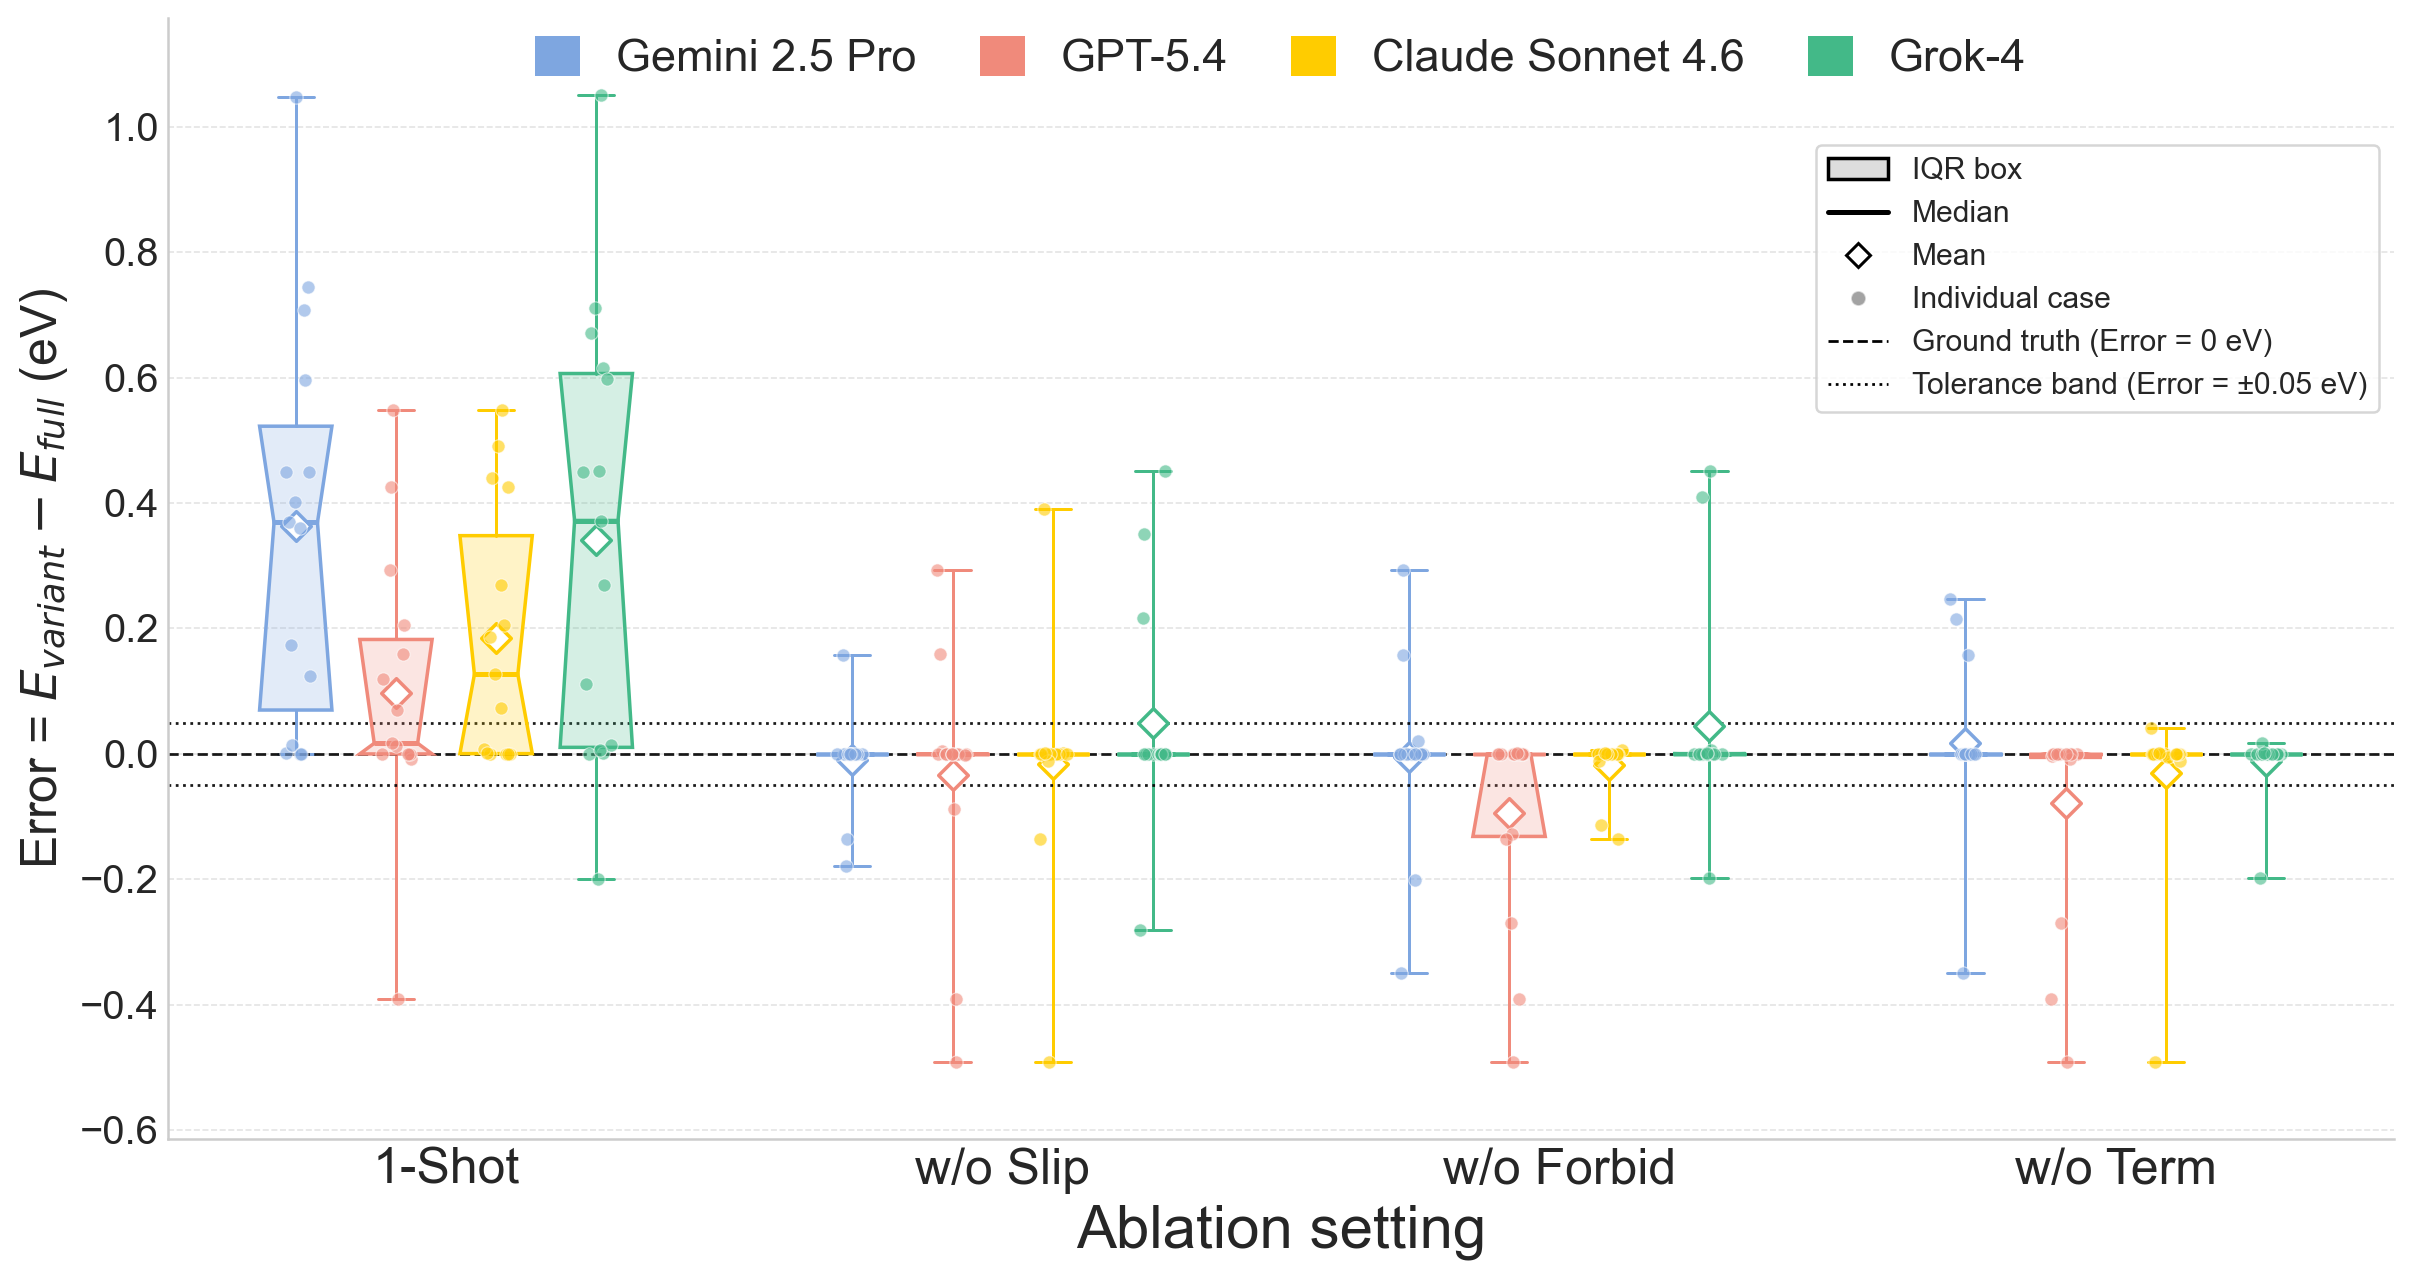

In [94]:
"""
Create a single-panel grouped summary plot for CMU20 LLM results.
Each ablation setting contains four color-coded LLM groups with horizontal spacing.
Visual encoding per group: IQR as two trapezoids, median line, mean diamond, min-max whiskers, and individual-case points.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon

# Use a clean white-grid style suitable for scientific figures.
plt.style.use("seaborn-v0_8-whitegrid")

# Configure typography to better match paper-style plots.
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Resolve the working directory so the notebook remains portable.
data_dir = Path.cwd()

# Define model metadata: CSV file and display color.
model_config = {
    "Gemini 2.5 Pro": {"file": "gemini.csv", "color": "#7EA6E0"},
    "GPT-5.4": {"file": "gpt.csv", "color": "#F08A7B"},
    "Claude Sonnet 4.6": {"file": "claude.csv", "color": "#FFCC00"},
    "Grok-4": {"file": "grok.csv", "color": "#43B988"},
}

# Plot only ablation settings on x-axis (excluding Full).
plot_order = ["1-Shot", "-Slip", "-Forbid", "-Term"]

# Load all model tables and normalize the column names because the CSV headers
# contain inconsistent leading spaces.
frames = {}
for model_name, cfg in model_config.items():
    df = pd.read_csv(data_dir / cfg["file"])
    df.columns = df.columns.str.strip()
    df["Case"] = df["Case"].astype(str).str.strip().str.zfill(2)
    df[["Full", *plot_order]] = df[["Full", *plot_order]].astype(float)

    # Convert raw energies to delta energies relative to Full for each case.
    for scenario in plot_order:
        df[scenario] = df[scenario] - df["Full"]

    df = df.sort_values("Case", key=lambda s: s.astype(int)).reset_index(drop=True)
    frames[model_name] = df

# Compute y-limits from all values.
all_values = []
for model_name in model_config:
    for scenario in plot_order:
        all_values.extend(frames[model_name][scenario].to_numpy(dtype=float).tolist())

y_min = float(np.nanmin(all_values))
y_max = float(np.nanmax(all_values))
y_pad = 0.08 * max(1e-6, y_max - y_min)
ylim = (y_min - y_pad, y_max + y_pad)

# Build one grouped panel.
fig, ax = plt.subplots(figsize=(13.5, 7.2), dpi=180)

rng = np.random.default_rng(2026)
model_names = list(model_config.keys())
n_models = len(model_names)

# Base x for each ablation setting and fixed horizontal offsets for each LLM.
x_base = np.arange(1, len(plot_order) + 1)
offset_span = 0.54
offsets = np.linspace(-offset_span / 2.0, offset_span / 2.0, n_models)

box_half_width = 0.065
neck_half_width = 0.6 * box_half_width

for offset, model_name in zip(offsets, model_names):
    cfg = model_config[model_name]
    color = cfg["color"]
    df = frames[model_name]

    values_by_setting = [df[scenario].to_numpy(dtype=float) for scenario in plot_order]
    x_positions = x_base + offset

    # Draw min-max whiskers while suppressing default rectangular boxes.
    ax.boxplot(
        values_by_setting,
        positions=x_positions,
        widths=2.0 * box_half_width,
        whis=(0, 100),
        patch_artist=True,
        showfliers=False,
        boxprops={"facecolor": "none", "edgecolor": "none", "linewidth": 0.0},
        whiskerprops={"color": color, "linewidth": 1.2},
        capprops={"color": color, "linewidth": 1.2},
        medianprops={"color": color, "linewidth": 0.0},
    )

    # Draw custom IQR body and summary markers per setting.
    for pos, values in zip(x_positions, values_by_setting):
        q1 = float(np.nanpercentile(values, 25))
        q3 = float(np.nanpercentile(values, 75))
        median_val = float(np.nanmedian(values))
        mean_val = float(np.nanmean(values))

        lower_trapezoid = Polygon(
            [
                (pos - box_half_width, q1),
                (pos + box_half_width, q1),
                (pos + neck_half_width, median_val),
                (pos - neck_half_width, median_val),
            ],
            closed=True,
            facecolor=to_rgba(color, 0.22),
            edgecolor=color,
            linewidth=1.4,
            zorder=3.1,
        )
        upper_trapezoid = Polygon(
            [
                (pos - neck_half_width, median_val),
                (pos + neck_half_width, median_val),
                (pos + box_half_width, q3),
                (pos - box_half_width, q3),
            ],
            closed=True,
            facecolor=to_rgba(color, 0.22),
            edgecolor=color,
            linewidth=1.4,
            zorder=3.1,
        )
        ax.add_patch(lower_trapezoid)
        ax.add_patch(upper_trapezoid)

        # Median line sits in the narrowed center section.
        ax.hlines(median_val, pos - neck_half_width, pos + neck_half_width, color=color, linewidth=2.0, zorder=3.8)

        # Mean diamond.
        ax.scatter(
            pos,
            mean_val,
            marker="D",
            s=70,
            facecolor="white",
            edgecolor=color,
            linewidth=1.4,
            zorder=4,
        )

        # Individual-case points with a small local jitter.
        jitter = rng.uniform(-0.028, 0.028, size=len(values))
        ax.scatter(
            np.full_like(values, pos, dtype=float) + jitter,
            values,
            s=28,
            color=color,
            edgecolors="white",
            linewidths=0.45,
            alpha=0.6,
            zorder=5,
        )

# Most important reference line: no difference from Full.
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.1, alpha=0.9, zorder=2)
'''ax.text(
    0.98,
    -0.01,
    "Ground truth", # 
    transform=ax.get_yaxis_transform(),
    fontsize=16,
    color="black",
    va="top",
    ha="left",
    #bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
)'''

ax.axhline(0.05, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)
ax.axhline(-0.05, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)
'''ax.text(
    0.88,
    0.06,
    "Tolerance band 0.05 eV", # 
    transform=ax.get_yaxis_transform(),
    fontsize=16,
    color="black",
    va="bottom",
    ha="left",
    #bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
)
'''


# LLM color legend (top row with colored squares).
llm_handles = [
    Patch(facecolor=model_config[name]["color"], edgecolor="none", label=name)
    for name in model_names
]
legend_llm = ax.legend(
    handles=llm_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=n_models,
    frameon=False,
    handlelength=1.0,
    handleheight=1.0,
    columnspacing=1.4,
    fontsize=18,
    
)
ax.add_artist(legend_llm)

# Visual-encoding legend.
style_legend_handles = [
    Patch(facecolor=to_rgba("#666666", 0.22), edgecolor="black", linewidth=1.4, label="IQR box"),
    Line2D([0], [0], color="black", linewidth=2.0, label="Median"),
    Line2D([0], [0], marker="D", linestyle="None", markersize=7, markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.2, label="Mean"),
    # Line2D([0], [0], color="black", linewidth=1.2, marker="_", markersize=12, label="Whisker (min-max)"),
    Line2D([0], [0], marker="o", linestyle="None", markersize=6, markerfacecolor="#666666", markeredgecolor="white", markeredgewidth=0.7, alpha=0.6, label="Individual case"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.1, label="Ground truth (Error = 0 eV)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.1, label="Tolerance band (Error = ±0.05 eV)"),
]
ax.legend(handles=style_legend_handles, bbox_to_anchor=(1.0, 0.9),fontsize=12, frameon=True)

# Axes formatting.
ax.set_xlim(0.5, len(plot_order) + 0.5)
ax.set_ylim(*ylim)
ax.set_xticks(x_base)
ax.set_xticklabels(["1-Shot", "w/o Slip", "w/o Forbid", "w/o Term"], fontsize=20) # we need to use the same labels as in the CSV for the x-axis, but we can format them more nicely here.
ax.set_xlabel("Ablation setting", fontsize=24)
ax.set_ylabel("Error = $E_{variant} - E_{full}$ (eV)", fontsize=20)
ax.tick_params(axis="y", labelsize=16)
ax.grid(True, axis="y", linestyle="--", linewidth=0.65, alpha=0.55)
ax.grid(False, axis="x")

# Keep spacing comfortable for publication use.
fig.tight_layout()

# Save a high-resolution figure for later reuse in papers or slides.
output_path = data_dir / "cmu20_llm_performance_comparison_violin_panels.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {output_path}")
plt.show()